**AF7. Producto Integrador de Aprendizaje**

**Librerías**

Se importan `numpy` para el manejo de vectores y operaciones matriciales, `solve_ivp` de `scipy` para resolver la ecuación diferencial del sistema dinámico (equivalente a `ode45` en MATLAB), y `matplotlib` para la generación de gráficos.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

**Modelo dinámico robot manipulador planar 2 GDL**

Se define la función matemática que representa la dinámica del manipulador basándose en la ecuación:
$$M(q)\ddot{q} + C(q, \dot{q})\dot{q} + g(q) + f_r(\dot{q}) = \tau$$

Donde:
* **$M(q)$**: Matriz de inercia.
* **$C(q, \dot{q})$**: Matriz de fuerzas centrípetas y de Coriolis.
* **$g(q)$**: Vector de pares gravitacionales.
* **$f_r(\dot{q})$**: Pares de fricción viscosa y de Coulomb.
* **$\tau$**: Torques externos aplicados a las articulaciones (hombro y codo).

La función despeja la aceleración articular ($\ddot{q}$) y retorna las derivadas de los estados para el integrador.

In [ ]:
def cap5_robot2gdl(t, x):
    # Estados: q1, q2 (posiciones), q1d, q2d (velocidades)
    q1, q2, q1d, q2d = x

    q = np.array([q1, q2])
    qp = np.array([q1d, q2d])

    # Matriz de inercia M(q)
    M = np.array([
        [3.117 + 0.2 * np.cos(q[1]), 0.108 + 0.1 * np.cos(q[1])],
        [0.108 + 0.1 * np.cos(q[1]), 0.108]
    ])

    # Matriz de fuerzas centrípetas y de coriolis C(q, qp)
    C = np.array([
        [-0.2 * np.sin(q[1]) * qp[1], -0.1 * np.sin(q[1]) * qp[1]],
        [ 0.1 * np.sin(q[1]) * qp[0],  0.0]
    ])

    # Vector de pares gravitacionales g(q)
    par_grav = np.array([
        39.3 * np.sin(q[0]) + 1.95 * np.sin(q[0] + q[1]),
        1.95 * np.sin(q[0] + q[1])
    ])

    # Vector de pares de fricción y Coulomb f_r(qp)
    # Usamos np.sign() que es la alternativa nativa y eficiente de NumPy para la función signo
    fr = np.array([
        1.86 * qp[0] + 1.93 * np.sign(qp[0]),
        0.16 * qp[1] + 0.3 * np.sign(qp[1])
    ])

    # Vector de torques tau(t)
    tau = np.array([
        (1 - np.exp(-0.8 * t)) * 32.0 + 56 * np.sin(16 * t + 0.1) + 12 * np.sin(20 * t + 0.15),
        (1 - np.exp(-1.8 * t)) * 1.2  + 8 * np.sin(26 * t + 0.08) + 2 * np.sin(12 * t + 0.34)
    ])

    # Aceleraciones articulares: q2p = M^-1 * (tau - C*qp - par_grav - fr)
    # np.linalg.solve es numéricamente más estable y rápido que inv()
    q2p = np.linalg.solve(M, tau - C @ qp - par_grav - fr)

    # Retorna las derivadas de los estados: [velocidades, aceleraciones]
    return [qp[0], qp[1], q2p[0], q2p[1]]



**Configuración de la Simulación**

Se establecen condiciones iniciales del robot (partiendo del reposo con posiciones y velocidades en cero), el tiempo de muestreo idéntico al del libro ($h = 0.0025\text{ s}$), y se ejecuta la integración numérica con tolerancias para asegurar la convergencia del algoritmo.

In [ ]:
ti = 0         # Tiempo inicial
h = 0.0025     # Incremento de tiempo
tf = 10        # Tiempo final

# Vector de tiempo estructurado igual al del libro
ts = np.arange(ti, tf + h, h)

# Condiciones iniciales [q1, q2, q1d, q2d] -> Robot en reposo
x0 = [0.0, 0.0, 0.0, 0.0]

# Ejecución del integrador numérico
# NOTA CRÍTICA: Se añade t_eval para forzar los pasos de tiempo exactos del libro
sol = solve_ivp(
    cap5_robot2gdl,
    [ti, tf],
    x0,
    t_eval=ts,
    rtol=1e-3,
    max_step=2.5e-3
)

# Extracción de resultados
t = sol.t
x = sol.y.T  # Transponemos para tener las variables en columnas igual que en MATLAB



**Gráfica**

Se extraen las columnas correspondientes a las posiciones articulares ($q_1$ para el hombro y $q_2$ para el codo), se convierten de radianes a grados utilizando `np.rad2deg`, y se grafican respecto al tiempo para verificar el comportamiento oscilatorio del robot manipulador planar de 2 GDL.

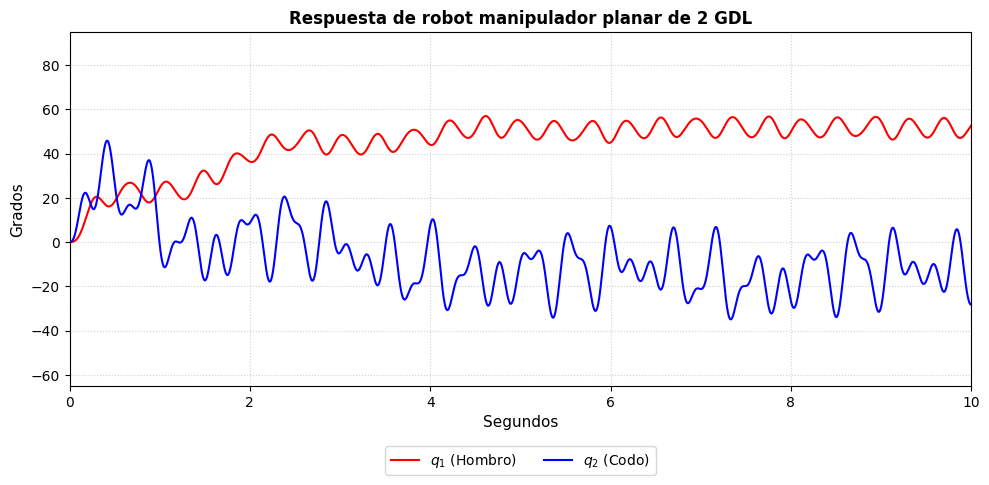

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(t, np.rad2deg(x[:, 0]), 'r-', label="$q_1$ (Hombro)")
plt.plot(t, np.rad2deg(x[:, 1]), 'b-', label="$q_2$ (Codo)")

plt.xlabel("Segundos", fontsize=11)
plt.ylabel("Grados", fontsize=11)
plt.title("Respuesta de robot manipulador planar de 2 GDL", fontsize=12, fontweight='bold')
plt.xlim(ti, tf)
plt.ylim(-65, 95)  # Ajustado para que coincida visualmente con la escala de la Figura 5.6 del libro
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()